C:\Users\KIIT\AppData\Local\Temp\ipykernel_4328\559981047.py:71: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(merged["return_fund"], merged["return_bench"])
c:\Users\KIIT\anaconda3\lib\site-packages\numpy\lib\function_base.py:2704: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\KIIT\anaconda3\lib\site-packages\numpy\lib\function_base.py:2704: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users\KIIT\AppData\Local\Temp\ipykernel_4328\559981047.py:71: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(merged["return_fund"], merged["return_bench"])
c:\Users\KIIT\anaconda3\lib\site-packages\numpy\lib\function_base.py:2704: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\KIIT\anaconda3\lib\site-packages\numpy\lib\function_base.py:2704: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
C:\Users

✅ Fund performance metrics computed and saved → reports/fund_scorecard.csv


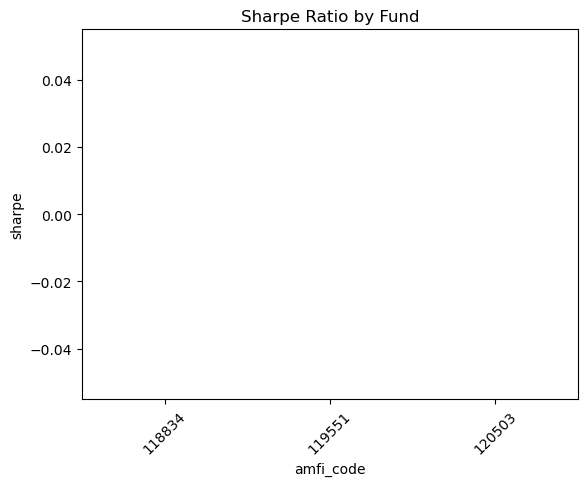

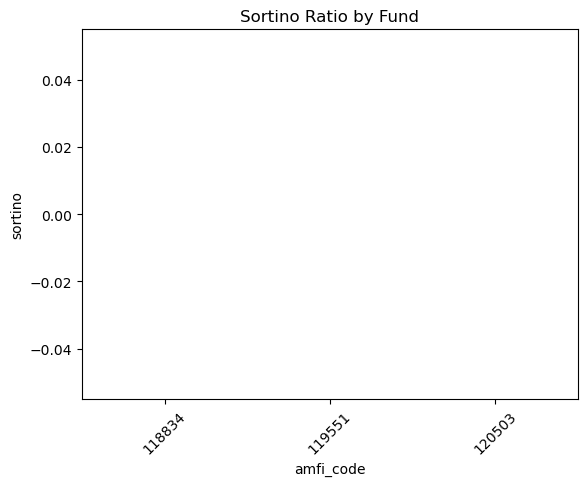

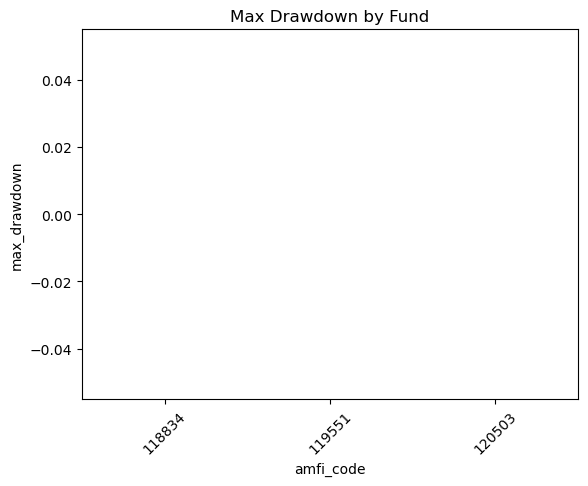

In [1]:
# Bluestock MF Capstone — Day 4: Fund Performance Analytics
# Author: Ayush Kumar Singh
# Date: 12 June 2026

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data/processed")

# Load NAV history
nav_history = pd.read_csv(DATA_DIR / "nav_history_clean.csv")

# Ensure correct columns
nav_history["nav_date"] = pd.to_datetime(nav_history["nav_date"])
nav_history = nav_history.sort_values(["amfi_code","nav_date"])

# -----------------------------
# 1️⃣ Compute daily returns
# -----------------------------
nav_history["return"] = nav_history.groupby("amfi_code")["nav_value"].pct_change()

# -----------------------------
# 2️⃣ Sharpe Ratio
# -----------------------------
risk_free_rate = 0.05/252  # daily risk-free rate
metrics = []

for code, df in nav_history.groupby("amfi_code"):
    mean_return = df["return"].mean()
    vol = df["return"].std()
    sharpe = (mean_return - risk_free_rate) / vol if vol != 0 else np.nan
    metrics.append({"amfi_code": code, "mean_return": mean_return, "volatility": vol, "sharpe": sharpe})

metrics_df = pd.DataFrame(metrics)

# -----------------------------
# 3️⃣ Sortino Ratio
# -----------------------------
def sortino_ratio(returns, rf=0.0):
    downside = returns[returns < 0].std()
    if downside == 0 or np.isnan(downside):
        return np.nan
    return (returns.mean() - rf) / downside

metrics_df["sortino"] = nav_history.groupby("amfi_code")["return"].apply(lambda r: sortino_ratio(r, risk_free_rate)).values

# -----------------------------
# 4️⃣ Max Drawdown
# -----------------------------
def max_drawdown(series):
    cum = (1+series).cumprod()
    peak = cum.cummax()
    dd = (cum - peak)/peak
    return dd.min()

metrics_df["max_drawdown"] = nav_history.groupby("amfi_code")["return"].apply(max_drawdown).values

# -----------------------------
# 5️⃣ Alpha & Beta (vs benchmark)
# -----------------------------
# Assume benchmark is first fund in dataset
benchmark_code = nav_history["amfi_code"].unique()[0]
benchmark = nav_history[nav_history["amfi_code"]==benchmark_code][["nav_date","return"]].set_index("nav_date")

alphas, betas = [], []
for code, df in nav_history.groupby("amfi_code"):
    merged = df.set_index("nav_date")[["return"]].join(benchmark, lsuffix="_fund", rsuffix="_bench").dropna()
    cov = np.cov(merged["return_fund"], merged["return_bench"])
    beta = cov[0,1]/cov[1,1] if cov[1,1]!=0 else np.nan
    alpha = merged["return_fund"].mean() - beta*merged["return_bench"].mean()
    alphas.append(alpha)
    betas.append(beta)

metrics_df["alpha"] = alphas
metrics_df["beta"] = betas

# -----------------------------
# 6️⃣ Fund Scorecard
# -----------------------------
metrics_df["score"] = (
    metrics_df["sharpe"].rank(ascending=False) +
    metrics_df["sortino"].rank(ascending=False) +
    metrics_df["alpha"].rank(ascending=False) -
    metrics_df["max_drawdown"].rank(ascending=True)
)

metrics_df.sort_values("score", ascending=False, inplace=True)
metrics_df.to_csv("../reports/fund_scorecard.csv", index=False)

print("✅ Fund performance metrics computed and saved → reports/fund_scorecard.csv")

# -----------------------------
# 7️⃣ Visualization
# -----------------------------
sns.barplot(data=metrics_df, x="amfi_code", y="sharpe")
plt.title("Sharpe Ratio by Fund")
plt.xticks(rotation=45)
plt.show()

sns.barplot(data=metrics_df, x="amfi_code", y="sortino")
plt.title("Sortino Ratio by Fund")
plt.xticks(rotation=45)
plt.show()

sns.barplot(data=metrics_df, x="amfi_code", y="max_drawdown")
plt.title("Max Drawdown by Fund")
plt.xticks(rotation=45)
plt.show()
